## Canny


### Implementación Paso a Paso de Canny (Desde Cero)

Para entender cómo funciona Canny por debajo, vamos a implementar cada una de sus fases en celdas separadas.

Primero, importaremos las librerías necesarias y generaremos una imagen sintética de prueba (con ruido) a la cual le aplicaremos el detector.


(259, 390)


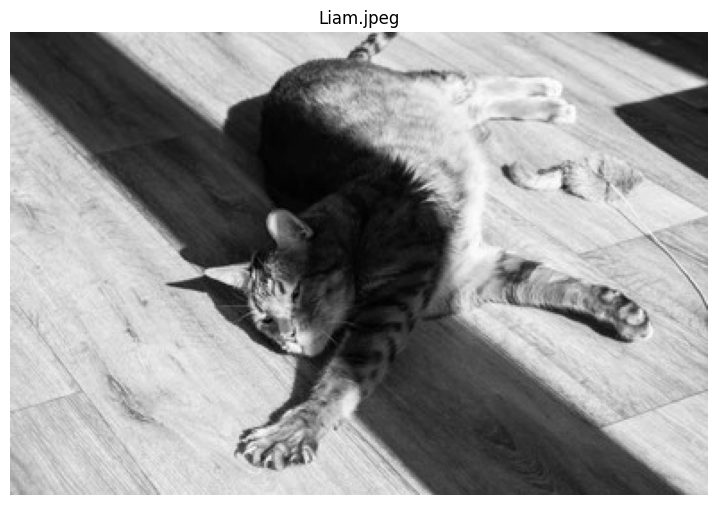

In [68]:
# pylint: skip-file
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Leemos la imagen real en escala de grises
img = cv2.imread("caty.jpg", cv2.IMREAD_GRAYSCALE)
print(img.shape)

if img is None:
    print("Error: No se pudo cargar la imagen 'liam3.jpeg'. Comprueba la ruta.")
else:
    plt.figure(figsize=(9, 9))
    plt.imshow(img, cmap="gray")
    plt.title("Liam.jpeg")
    plt.axis("off")
    plt.show()

#### Paso 1: Reducción de Ruido (Filtro Gaussiano)

El algoritmo de Canny asume que el ruido de alta frecuencia, característico en la captura de luz por sensores de cámara reales, se puede equivocar con bordes verdaderos (ya que cambia radicalmente de luminancia el vecino inmediato del píxel ruidoso de golpe a un valor muy oscuro o claro).

Al filtrar la imagen usando una gaussiana de $5 \times 5$, suprimimos efectivamente el ruido y evitamos falsas activaciones, preservando los contornos estructurales verdaderos gracias a la forma tipo "campana" en los pesos del filtro.


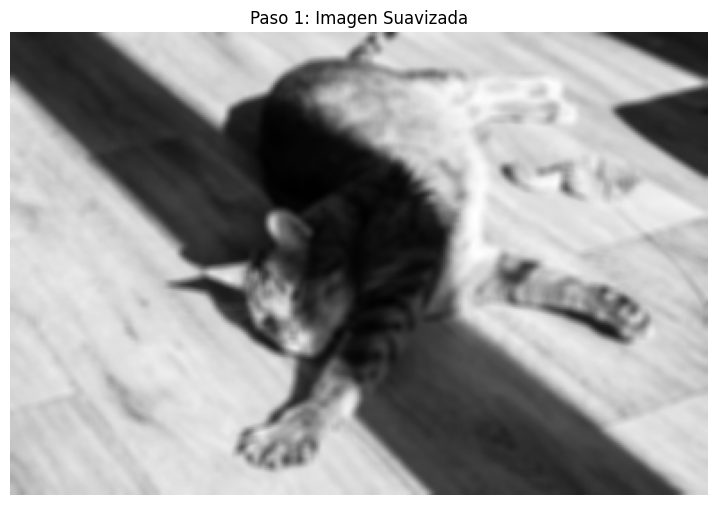

In [79]:
# Omitiremos el padding manual, usando GaussianBlur
# Utilizamos una matriz de 5x5 con ~desviación de 1.4, bastante estándar.
img_blur = cv2.GaussianBlur(img, (5, 5), 3)

plt.figure(figsize=(9, 9))
plt.imshow(img_blur, cmap="gray")
plt.title("Paso 1: Imagen Suavizada")
plt.axis("off")
plt.show()

#### Paso 2: Cálculo del Gradiente y Direccionalidad (Sobel)

Ahora debemos encontrar qué tan rápido cambian los diferentes píxeles del eje X y del eje Y. Mientras más agudamente cambia de muy oscuro a muy brillante (alto gradiente), más asimilamos a que existe entonces un _borde_ o un límite de una forma. También nos interesa mucho la dirección $\theta$.

$$ \nabla G = \sqrt{I_x^2 + I_y^2} \quad \text{y} \quad \theta = \arctan(I_y / I_x) $$


(259, 390)

(259, 390)


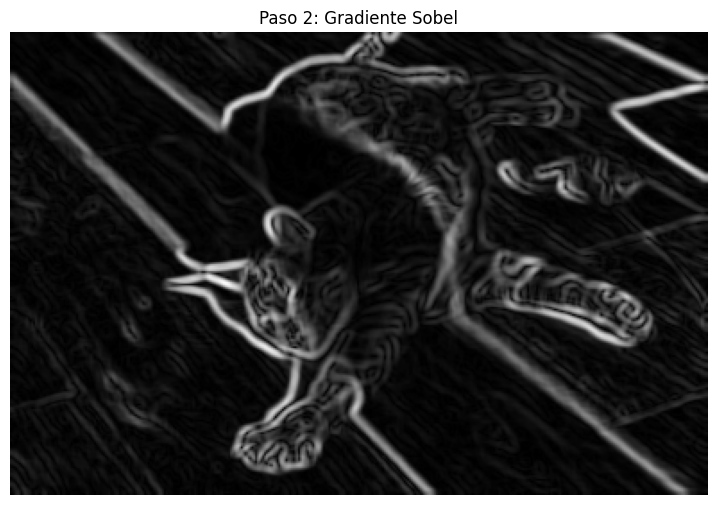

In [80]:
# Aplicamos kernels Sobel en X e Y
Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)


Ix = cv2.filter2D(img_blur, cv2.CV_64F, Kx)
Iy = cv2.filter2D(img_blur, cv2.CV_64F, Ky)

# 1) Magnitud del gradiente
G = np.hypot(Ix, Iy)
print(G.shape)
print()

# G = G / G.max() * 255  # Normalizado p/ ver mejor

# 2) Dirección (ángulo en grados [0, 180])
angle = np.arctan2(Iy, Ix) * (180.0 / np.pi)
angle[angle < 0] += 180

print(angle.shape)

plt.figure(figsize=(9, 9))
plt.imshow(G, cmap="gray")
plt.title("Paso 2: Gradiente Sobel")
plt.axis("off")
plt.show()

#### Paso 3: Supresión de No-Máximos (Non-maximum suppression - NMS)

A este punto, nuestros "bordes" son bastante gruesos. Lo normal para bordes, en OpenCV o detección gráfica con Canny, es querer un grosor de un solo píxel.
Por cada grupo de píxeles en el mismo ángulo, nos mantenemos o "suprimimos" aquellos que no son el valor mayor con respecto a sus 2 vecinos directos paralelos a la dirección de ese borde.


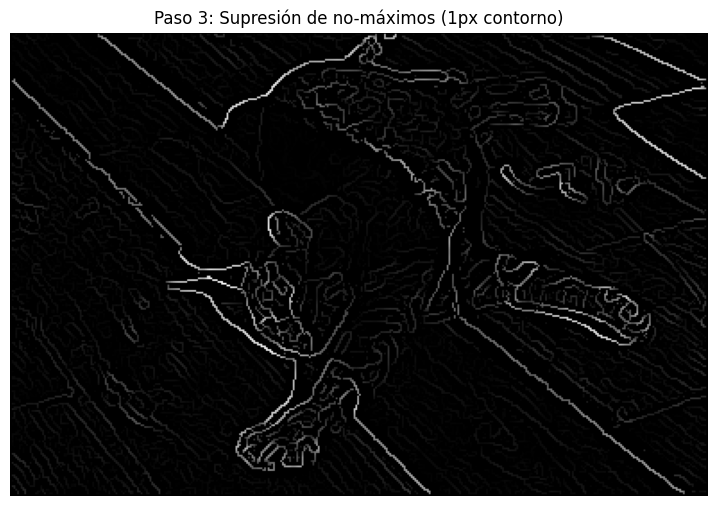

In [81]:
M, N = img.shape
Z = np.zeros((M, N), dtype=np.int32)

for i in range(1, M - 1):
    for j in range(1, N - 1):
        q, r = 255, 255

        if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
            q, r = G[i, j + 1], G[i, j - 1]
        elif 22.5 <= angle[i, j] < 67.5:
            q, r = G[i + 1, j - 1], G[i - 1, j + 1]
        elif 67.5 <= angle[i, j] < 112.5:
            q, r = G[i + 1, j], G[i - 1, j]
        elif 112.5 <= angle[i, j] < 157.5:
            q, r = G[i - 1, j - 1], G[i + 1, j + 1]

        if (G[i, j] >= q) and (G[i, j] >= r):
            Z[i, j] = G[i, j]
        else:
            Z[i, j] = 0

plt.figure(figsize=(9, 9))
plt.imshow(Z, cmap="gray")
plt.title("Paso 3: Supresión de no-máximos (1px contorno)")
plt.axis("off")
plt.show()

#### Paso 4: Umbralización Doble

Aquí es donde los parámetros clásicos `threshold1` y `threshold2` de la función `cv2.Canny()` entran. Clasificaremos en Píxeles fuertes o débiles.
Todo aquel cuyo gradiente sea muy bajo (ruido sutil, una arruga) se eliminará por debajo de `threshold1`.


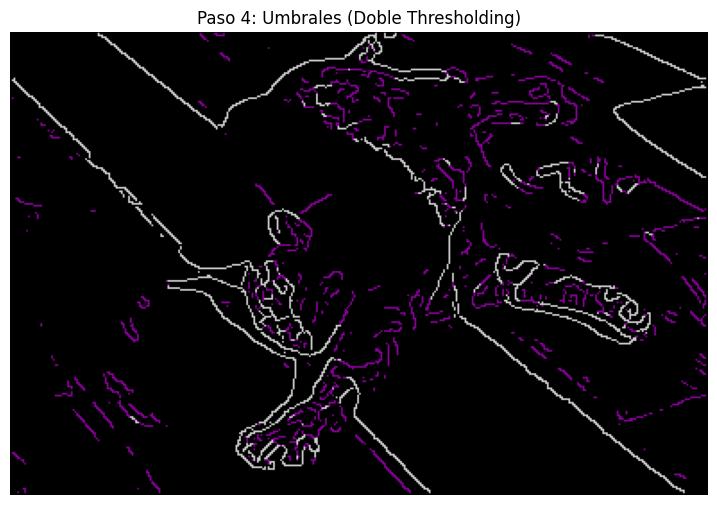

In [85]:
low_threshold = 50
high_threshold = 110

res = np.zeros((M, N), dtype=np.int32)
weak_val = np.int32(25)
strong_val = np.int32(255)

strong_i, strong_j = np.where(Z >= high_threshold)
zeros_i, zeros_j = np.where(Z < low_threshold)
weak_i, weak_j = np.where((Z <= high_threshold) & (Z >= low_threshold))

res[strong_i, strong_j] = strong_val
to_strong = np.zeros(res.shape, dtype=bool)
res[weak_i, weak_j] = weak_val


plt.figure(figsize=(9, 9))
plt.imshow(res, cmap="nipy_spectral")
plt.title("Paso 4: Umbrales (Doble Thresholding)")
plt.axis("off")
plt.show()

#### Paso 5: Seguimiento por Histéresis (Edge Tracking)

Este paso salva bordes débiles pero que están estructuralmente _conectados_ con verdaderos bordes fuertes. Si un débil no toca (usando las 8 direcciones vecinas de un píxel) a uno fuerte, se declara como falso falso borde derivado del ruido y se pone a 0.


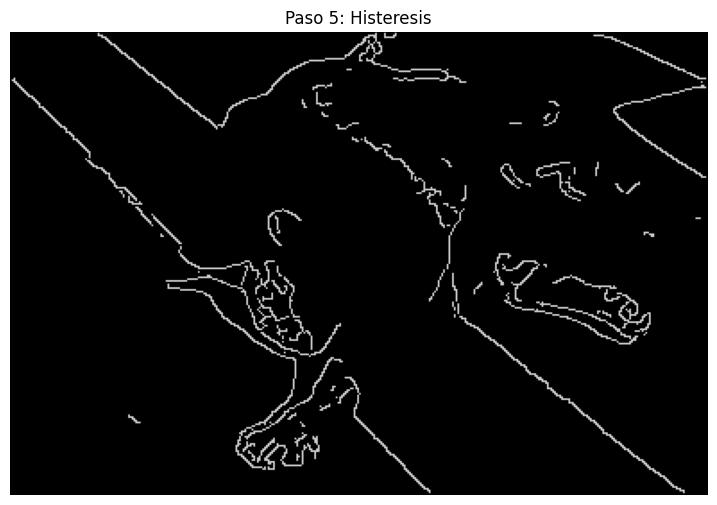

In [86]:
for i in range(1, M - 1):
    for j in range(1, N - 1):
        if res[i, j] == weak_val:
            if (
                (res[i + 1, j - 1] == strong_val)
                or (res[i + 1, j] == strong_val)
                or (res[i + 1, j + 1] == strong_val)
                or (res[i, j - 1] == strong_val)
                or (res[i, j + 1] == strong_val)
                or (res[i - 1, j - 1] == strong_val)
                or (res[i - 1, j] == strong_val)
                or (res[i - 1, j + 1] == strong_val)
            ):
                to_strong[i, j] = 1

res[weak_i, weak_j] = to_strong[weak_i, weak_j] * strong_val

plt.figure(figsize=(9, 9))
plt.imshow(res, cmap="nipy_spectral")
plt.title("Paso 5: Histeresis")
plt.axis("off")
plt.show()

#### Comparación con OpenCV


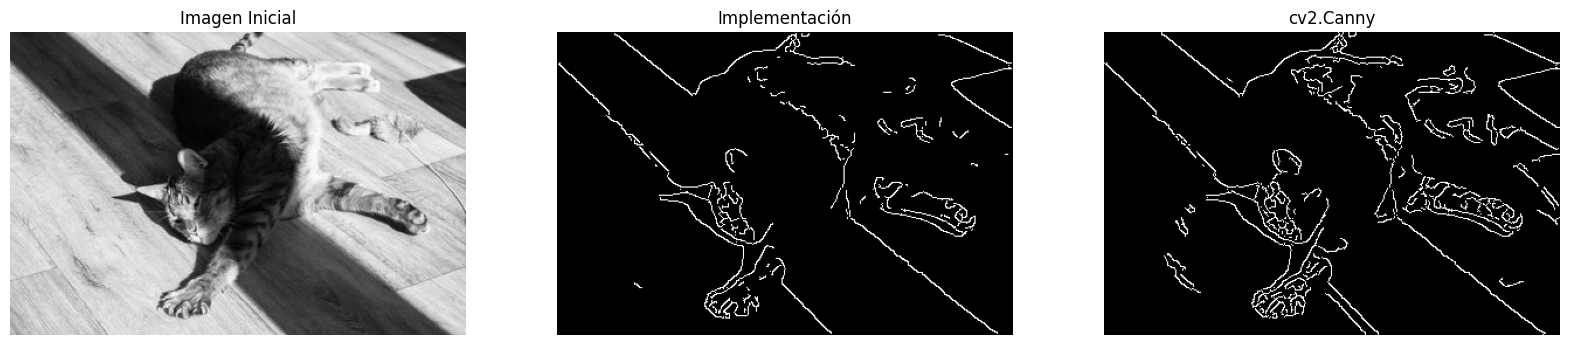

In [87]:
canny_from_scratch = np.uint8(res)

# Comparación con OpenCV
canny_cv2 = cv2.Canny(img_blur, low_threshold, high_threshold)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Imagen Inicial")
axs[0].axis("off")

axs[1].imshow(canny_from_scratch, cmap="gray")
axs[1].set_title("Implementación")
axs[1].axis("off")

axs[2].imshow(canny_cv2, cmap="gray")
axs[2].set_title("cv2.Canny")
axs[2].axis("off")

plt.show()